In [1]:
import pandas as pd
import torch 
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader

In [2]:
raw_data = pd.read_csv('../data/btcusd_1-min_data.csv',index_col=0)

In [3]:
from preprocess import prepare_intraday_data, calculate_daily_components
intraday_data = prepare_intraday_data(raw_data) 
daily_data = calculate_daily_components(intraday_data)
benchmark_frame = pd.read_csv('../data/benchmark_predictions.csv', parse_dates=['date'])
benchmark_test_start = benchmark_frame['date'].min()
from dataloader import create_dataloaders
# 创建DataLoader，并按基准文件的测试起始日切分
train_loader, test_loader, data_metadata = create_dataloaders(
    daily_data,
    batch_size=32,
    return_metadata=True,
    test_start_date=benchmark_test_start
 )
print(f"CNN测试集起始日期: {data_metadata['test_dates'][0].date()}")
print(f"基准测试集起始日期: {benchmark_test_start.date()}")

Train shape: (4091, 1, 16, 16)
Test shape:  (1029, 1, 16, 16)
CNN测试集起始日期: 2023-04-04
基准测试集起始日期: 2023-04-04


In [4]:
# 检查DataLoader的基本信息
print(f"训练集batch数量: {len(train_loader)}")
print(f"测试集batch数量: {len(test_loader)}")

# 获取一个batch的数据（多任务：图像、回归标签、分类标签）
images, y_reg, y_cls = next(iter(train_loader))
print(f"单个batch图像形状: {images.shape}")  # 应该是 [batch_size, 1, 16, 16]
print(f"单个batch回归标签形状: {y_reg.shape}")
print(f"单个batch分类标签形状: {y_cls.shape}")
print(f"回归标签示例 (前5个): {y_reg[:5].numpy()}")
print(f"分类标签示例 (前10个): {y_cls[:10].numpy()}")

# 检查类别分布
all_cls_labels = []
for _, _, batch_cls_labels in train_loader:
    all_cls_labels.append(batch_cls_labels.numpy())
all_cls_labels = np.concatenate(all_cls_labels)
print(f"训练集分类类别分布 - 0: {(all_cls_labels == 0).sum()}, 1: {(all_cls_labels == 1).sum()}")

# 检查回归标签统计
all_reg_labels = []
for _, batch_reg_labels, _ in train_loader:
    all_reg_labels.append(batch_reg_labels.numpy())
all_reg_labels = np.concatenate(all_reg_labels)
print(f"训练集回归标签统计 - 均值: {all_reg_labels.mean():.4f}, 标准差: {all_reg_labels.std():.4f}, 范围: [{all_reg_labels.min():.4f}, {all_reg_labels.max():.4f}]")

训练集batch数量: 128
测试集batch数量: 33
单个batch图像形状: torch.Size([32, 1, 16, 16])
单个batch回归标签形状: torch.Size([32])
单个batch分类标签形状: torch.Size([32])
回归标签示例 (前5个): [-0.14762397 -0.14389096  2.5951672  -0.17682084 -0.16927686]
分类标签示例 (前10个): [1 1 0 1 0 0 1 1 0 1]
训练集分类类别分布 - 0: 1849, 1: 2242
训练集回归标签统计 - 均值: 0.0000, 标准差: 1.0000, 范围: [-0.1803, 36.4678]


In [5]:
# 导入CNN模型和训练函数
from model import CNN_HAR_KS, train_model, evaluate_model, export_test_predictions
# 设置设备并实例化模型
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

# 创建模型实例
model = CNN_HAR_KS().to(device)

# 检查模型结构
print("模型结构:")
print(model)

# 计算参数数量
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"总参数数量: {total_params:,}")
print(f"可训练参数数量: {trainable_params:,}")

# 使用一个batch测试前向传播（多任务）
images, y_reg, y_cls = next(iter(train_loader))
images = images.to(device)
y_reg = y_reg.to(device)
y_cls = y_cls.to(device)

with torch.no_grad():
    reg_output, cls_output = model(images)
    print(f"\n测试前向传播（多任务）:")
    print(f"输入形状: {images.shape}")
    print(f"回归输出形状: {reg_output.shape}")
    print(f"分类输出形状: {cls_output.shape}")
    # 分类预测：使用sigmoid激活和阈值0.5
    cls_pred = (torch.sigmoid(cls_output).view(-1) > 0.5).long()
    print(f"分类预测: {cls_pred[:10].cpu().numpy()}")
    print(f"真实分类标签: {y_cls[:10].cpu().numpy()}")
    print(f"真实回归标签示例: {y_reg[:5].cpu().numpy()}")

使用设备: cuda
模型结构:
CNN_HAR_KS(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=4096, out_features=64, bias=True)
  (relu3): ReLU()
  (fc_reg): Linear(in_features=64, out_features=1, bias=True)
  (fc_cls): Linear(in_features=64, out_features=1, bias=True)
)
总参数数量: 281,154
可训练参数数量: 281,154

测试前向传播（多任务）:
输入形状: torch.Size([32, 1, 16, 16])
回归输出形状: torch.Size([32, 1])
分类输出形状: torch.Size([32, 1])
分类预测: [0 0 0 0 0 0 0 0 0 0]
真实分类标签: [1 0 1 1 1 1 0 1 0 0]
真实回归标签示例: [-0.0044042  -0.09529167  0.634705   -0.14893433  0.00262782]


In [6]:
# 训练多任务模型
print("开始训练多任务模型...")
num_epochs = 50  # 可以根据需要调整

history = train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    num_epochs=num_epochs,
    device=device
)

print("\n多任务训练完成!")
print(f"最终测试损失: {history['test_loss'][-1]:.4f}")
print(f"最终测试回归MSE: {history['test_reg_mse'][-1]:.4f}")
print(f"最终测试分类准确率: {history['test_cls_acc'][-1]:.4f}")

开始训练多任务模型...
Starting multi-task training on cuda...
Epoch [1/50] Loss: 1.1381 | Train Reg MSE: 0.8979 | Train Cls Acc: 0.5431 | Test Loss: 0.6938 | Test Reg MSE: 0.0042 | Test Cls Acc: 0.5112
Epoch [2/50] Loss: 1.0780 | Train Reg MSE: 0.7859 | Train Cls Acc: 0.5524 | Test Loss: 0.7062 | Test Reg MSE: 0.0191 | Test Cls Acc: 0.5112
Epoch [3/50] Loss: 1.0255 | Train Reg MSE: 0.6766 | Train Cls Acc: 0.5453 | Test Loss: 0.6938 | Test Reg MSE: 0.0011 | Test Cls Acc: 0.5112
Epoch [4/50] Loss: 1.0316 | Train Reg MSE: 0.6979 | Train Cls Acc: 0.5495 | Test Loss: 0.6915 | Test Reg MSE: 0.0012 | Test Cls Acc: 0.5598
Epoch [5/50] Loss: 1.0406 | Train Reg MSE: 0.7133 | Train Cls Acc: 0.5556 | Test Loss: 0.6979 | Test Reg MSE: 0.0146 | Test Cls Acc: 0.5102
Epoch [6/50] Loss: 0.9965 | Train Reg MSE: 0.6411 | Train Cls Acc: 0.5705 | Test Loss: 0.6931 | Test Reg MSE: 0.0132 | Test Cls Acc: 0.5870
Epoch [7/50] Loss: 0.9496 | Train Reg MSE: 0.5632 | Train Cls Acc: 0.5815 | Test Loss: 0.6871 | Test Reg MS

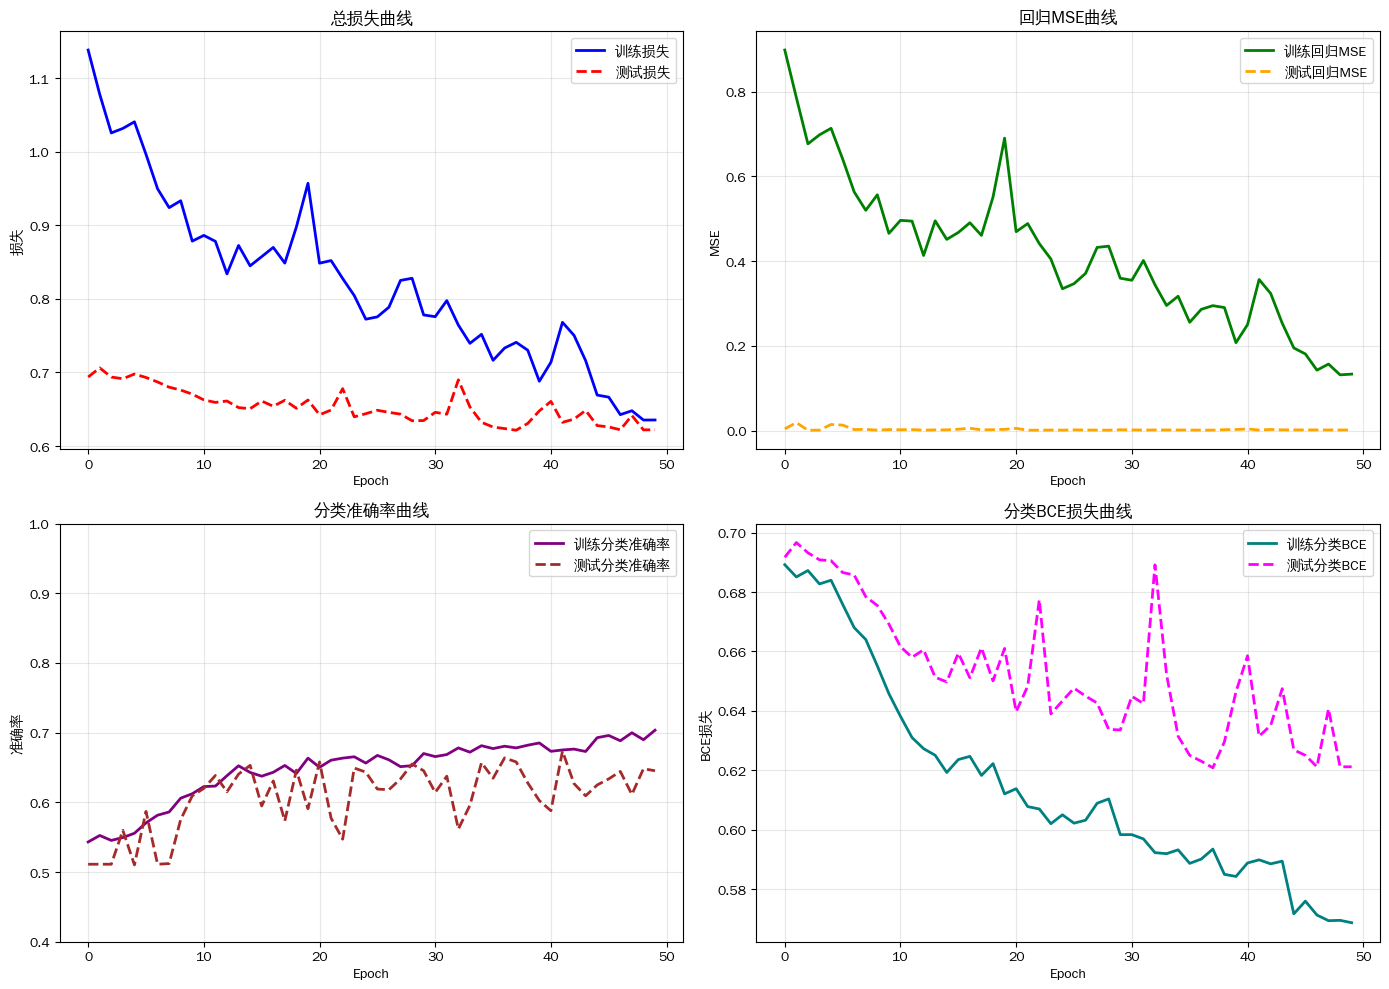

最佳测试分类准确率: 0.6735 (Epoch 42)
最佳测试回归MSE: 0.0011 (Epoch 3)
对应训练损失: 0.7681
当前 matplotlib 中文字体: WenQuanYi Zen Hei
多任务模型已保存为 cnn_har_ks_multitask_model.pth


In [7]:
# 可视化多任务训练结果
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 为 matplotlib 选择一个可用的中文字体，避免中文标题和标签告警
font_candidates = [
    'Noto Sans CJK SC',
    'WenQuanYi Zen Hei',
    'Droid Sans Fallback',
    'SimHei',
    'Microsoft YaHei',
]
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
selected_font = next((font for font in font_candidates if font in available_fonts), None)
if selected_font:
    plt.rcParams['font.sans-serif'] = [selected_font, *plt.rcParams.get('font.sans-serif', [])]
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 绘制总损失曲线
axes[0, 0].plot(history['train_loss'], label='训练损失', color='blue', linewidth=2)
axes[0, 0].plot(history['test_loss'], label='测试损失', color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('损失')
axes[0, 0].set_title('总损失曲线')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# 2. 绘制回归MSE曲线
axes[0, 1].plot(history['train_reg_mse'], label='训练回归MSE', color='green', linewidth=2)
axes[0, 1].plot(history['test_reg_mse'], label='测试回归MSE', color='orange', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MSE')
axes[0, 1].set_title('回归MSE曲线')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# 3. 绘制分类准确率曲线
axes[1, 0].plot(history['train_cls_acc'], label='训练分类准确率', color='purple', linewidth=2)
axes[1, 0].plot(history['test_cls_acc'], label='测试分类准确率', color='brown', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('准确率')
axes[1, 0].set_title('分类准确率曲线')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()
axes[1, 0].set_ylim([0.4, 1.0])

# 4. 绘制分类BCE损失曲线
axes[1, 1].plot(history['train_cls_bce'], label='训练分类BCE', color='teal', linewidth=2)
axes[1, 1].plot(history['test_cls_bce'], label='测试分类BCE', color='magenta', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('BCE损失')
axes[1, 1].set_title('分类BCE损失曲线')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# 打印最佳结果
best_epoch_cls = np.argmax(history['test_cls_acc'])
best_epoch_reg = np.argmin(history['test_reg_mse'])
print(f"最佳测试分类准确率: {history['test_cls_acc'][best_epoch_cls]:.4f} (Epoch {best_epoch_cls+1})")
print(f"最佳测试回归MSE: {history['test_reg_mse'][best_epoch_reg]:.4f} (Epoch {best_epoch_reg+1})")
print(f"对应训练损失: {history['train_loss'][best_epoch_cls]:.4f}")
if selected_font:
    print(f"当前 matplotlib 中文字体: {selected_font}")
else:
    print("未检测到可用中文字体，图表中文可能仍然无法正常显示。")

# 保存模型（可选）
torch.save(model.state_dict(), 'cnn_har_ks_multitask_model.pth')
print("多任务模型已保存为 cnn_har_ks_multitask_model.pth")

In [8]:
from pathlib import Path

output_path = Path('../data/cnn_har_ks_multitask_predictions.csv')
benchmark_path = Path('../data/benchmark_predictions.csv')

aligned_predictions = export_test_predictions(
    model=model,
    test_loader=test_loader,
    metadata=data_metadata,
    device=device,
    benchmark_path=benchmark_path,
    output_path=output_path,
 )

print(f"对齐后预测结果已保存到: {output_path.resolve()}")
print(f"输出行数: {len(aligned_predictions)}")
print(f"起始日期: {aligned_predictions['date'].min().date()}")
print(f"结束日期: {aligned_predictions['date'].max().date()}")
display(aligned_predictions.head())

对齐后预测结果已保存到: /home/myj/Notes/Term2/Project/FDAproject/data/cnn_har_ks_multitask_predictions.csv
输出行数: 1028
起始日期: 2023-04-04
结束日期: 2026-01-26


,date,true_rv,cnn_pred,true_cls,cnn_cls_logit,cnn_cls_prob,cnn_cls_pred
0,2023-04-04,0.000778,0.000589,0,0.109887,0.527444,1
1,2023-04-05,0.000582,0.000227,1,0.457618,0.612449,1
2,2023-04-06,0.000310,0.000400,1,0.203846,0.550786,1
3,2023-04-07,0.000179,0.000771,1,-0.411708,0.398503,0
4,2023-04-08,0.000079,0.000650,1,-0.461324,0.386672,0


In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.stats.diagnostic import acorr_ljungbox

def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)

    y_pred_safe = np.maximum(y_pred, 1e-8)
    ratio = y_true / y_pred_safe
    qlike = np.mean(ratio - np.log(ratio) - 1)

    return mse, mae, qlike

benchmark_eval = pd.read_csv(benchmark_path, parse_dates=['date'])
benchmark_eval['date'] = pd.to_datetime(benchmark_eval['date']).dt.normalize()

evaluation_frame = aligned_predictions.merge(
    benchmark_eval[['date', 'garch_pred', 'ewma_pred']],
    on='date',
    how='left'
 )

model_predictions = {
    'CNN-HAR-KS': evaluation_frame['cnn_pred'],
    'GARCH(1,1)': evaluation_frame['garch_pred'],
    'EWMA': evaluation_frame['ewma_pred'],
}

metrics_rows = []
for model_name, predictions in model_predictions.items():
    valid_frame = evaluation_frame[['true_rv']].copy()
    valid_frame['pred'] = predictions
    valid_frame = valid_frame.dropna()

    mse, mae, qlike = compute_metrics(valid_frame['true_rv'], valid_frame['pred'])
    metrics_rows.append({
        'Model': model_name,
        'MSE': mse,
        'MAE': mae,
        'QLIKE': qlike,
        'SampleSize': len(valid_frame),
    })

metrics_summary = pd.DataFrame(metrics_rows)
print('样本外误差指标：')
display(metrics_summary)

cnn_mse = metrics_summary.loc[metrics_summary['Model'] == 'CNN-HAR-KS', 'MSE'].iloc[0]
garch_mse = metrics_summary.loc[metrics_summary['Model'] == 'GARCH(1,1)', 'MSE'].iloc[0]
ewma_mse = metrics_summary.loc[metrics_summary['Model'] == 'EWMA', 'MSE'].iloc[0]
print(f"CNN-HAR-KS 相比 GARCH 的 MSE 改进: {(garch_mse - cnn_mse) / garch_mse * 100:.2f}%")
print(f"CNN-HAR-KS 相比 EWMA 的 MSE 改进: {(ewma_mse - cnn_mse) / ewma_mse * 100:.2f}%")

residual_frame = evaluation_frame[['date', 'true_rv', 'cnn_pred', 'garch_pred', 'ewma_pred']].copy()
residual_frame['cnn_residual'] = residual_frame['true_rv'] - residual_frame['cnn_pred']
residual_frame['garch_residual'] = residual_frame['true_rv'] - residual_frame['garch_pred']
residual_frame['ewma_residual'] = residual_frame['true_rv'] - residual_frame['ewma_pred']

print('\n残差 Ljung-Box 检验：')
for label, column in [
    ('CNN-HAR-KS', 'cnn_residual'),
    ('GARCH(1,1)', 'garch_residual'),
    ('EWMA', 'ewma_residual'),
]:
    residuals = residual_frame[column].dropna()
    lb_result = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
    print(f"\n{label}:")
    display(lb_result)

样本外误差指标：


,Model,MSE,MAE,QLIKE,SampleSize
0,CNN-HAR-KS,7.989715e-07,0.000597,6194.291246,1028
1,"GARCH(1,1)",4.398437e-07,0.000437,0.362221,1028
2,EWMA,4.162003e-07,0.000349,0.337428,1028


CNN-HAR-KS 相比 GARCH 的 MSE 改进: -81.65%
CNN-HAR-KS 相比 EWMA 的 MSE 改进: -91.97%

残差 Ljung-Box 检验：

CNN-HAR-KS:


,lb_stat,lb_pvalue
10,206.815227,6.103847e-39
20,232.661905,3.501398e-38



GARCH(1,1):


,lb_stat,lb_pvalue
10,125.959584,3.110524e-22
20,168.364428,1.802117e-25



EWMA:


,lb_stat,lb_pvalue
10,246.061560,3.651649e-47
20,289.103989,1.349053e-49
